# 05 – Python Analytics Workflow: Data Cleaning Showcase

**Goal:** Take a deliberately messy sales dataset and turn it into a clean,
analysis-ready table — then compute key business metrics (KPIs).

This notebook demonstrates a realistic end-to-end cleaning pipeline in pandas:

1. **Inspect** the raw data and identify quality issues
2. **Clean** step by step (each problem handled explicitly and documented)
3. **Validate** the result
4. **Analyse** — compute KPIs and a short summary

The raw file `data/raw/messy_sales.csv` contains common real-world problems:
inconsistent casing & typos in categories, mixed date formats, German vs.
international decimal notation, stray currency symbols, leading/trailing
whitespace, missing values, duplicate rows, and invalid quantities.

> Part of the analytics portfolio. Companion to `03_sql_foundations` and
> `04_sql_advanced_cases`, but focused on the **Python / pandas** side of the workflow.

## 1. Setup & load raw data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("data/raw/messy_sales.csv")
CLEAN = Path("data/clean/sales_clean.csv")

df_raw = pd.read_csv(RAW, dtype=str)   # read everything as string first — safer for messy data
print(f"Rows: {len(df_raw)} | Columns: {list(df_raw.columns)}")
df_raw.head(10)

Rows: 228 | Columns: ['order_id', 'date', 'product', 'city', 'quantity', 'unit_price']


,order_id,date,product,city,quantity,unit_price
0,1138,2024/11/12,Moniter,Hamburg,1,199.00
1,1095,2024/05/29,Moniter,Köln,5,199.00
2,1037,2024-03-06,Monitor,Köln,1,"199,00"
3,1053,2024/11/09,tastatur,NaN,5,49.00
4,1202,03/05/2024,Mouse,koln,2,25.00 €
5,1006,21/11/2024,Tastatur,koln,3,"49,00"
6,1215,19/12/2024,Tastatur,Hamburg,4,"49,00"
7,1169,2024/05/27,Mouse,Berlin,2,"25,00 €"
8,1187,2024-08-19,Monitor,BERLIN,2,199.00
9,1160,24.03.2024,Mouse,Hamburg,2,25.00


## 2. Inspect — where is the mess?

Before touching anything, we profile the data to understand the problems.

In [2]:
# Missing values per column
print("Missing values per column:")
print(df_raw.isna().sum(), "\n")

# Empty strings (not caught by isna)
print("Empty strings per column:")
print((df_raw == "").sum(), "\n")

# Full-row duplicates
print("Duplicate rows:", df_raw.duplicated().sum())

Missing values per column:
order_id       0
date           0
product        0
city          12
quantity       0
unit_price     6
dtype: int64 

Empty strings per column:
order_id      0
date          0
product       0
city          0
quantity      0
unit_price    0
dtype: int64 

Duplicate rows: 7


In [3]:
# Unique raw values in categorical columns reveal typos & casing issues
print("PRODUCT — raw distinct values:")
print(sorted(df_raw['product'].dropna().unique()), "\n")
print("CITY — raw distinct values:")
print(sorted(df_raw['city'].dropna().unique()), "\n")
print("UNIT_PRICE — sample of raw values:")
print(df_raw['unit_price'].dropna().unique()[:12], "\n")
print("DATE — sample of raw values:")
print(df_raw['date'].dropna().unique()[:8])

PRODUCT — raw distinct values:
[' Notebook', ' Tastatur ', 'MAUS', 'Maus', 'Moniter', 'Monitor', 'Monitor ', 'Mouse', 'NOTEBOOK', 'Notbook', 'Notebook', 'Tastatur', 'Tastaur', 'maus', 'monitor', 'notebook', 'tastatur'] 

CITY — raw distinct values:
[' Berlin', 'BERLIN', 'Berlin', 'Hamburg', 'Hamburg ', 'Koeln', 'Köln', 'Muenchen', 'MÜNCHEN', 'München', 'berlin', 'hamburg', 'koln', 'munchen'] 

UNIT_PRICE — sample of raw values:
<StringArray>
[  '199.00',   '199,00',    '49.00',  '25.00 €',    '49,00',  '25,00 €',
    '25.00',   '899.00',    '25,00', '199.00 €', '899,00 €',   '899,00']
Length: 12, dtype: str 

DATE — sample of raw values:
<StringArray>
['2024/11/12', '2024/05/29', '2024-03-06', '2024/11/09', '03/05/2024',
 '21/11/2024', '19/12/2024', '2024/05/27']
Length: 8, dtype: str


**Findings:**

- `product` and `city` have casing differences, leading/trailing spaces, and typos (e.g. *Notbook*, *Moniter*, *Mouse*, *Muenchen*).
- `unit_price` mixes `.` and `,` as decimal separators and sometimes carries a `€` sign — currently unusable as a number.
- `date` appears in **four** different formats.
- There are missing cities, empty prices, duplicate rows, and some invalid quantities.

We fix these one by one.

## 3. Clean step by step

### 3.1 Remove duplicate rows

In [4]:
df = df_raw.copy()
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df)}")

Removed 7 duplicate rows. Remaining: 221


### 3.2 Standardise text columns (strip whitespace + fix casing/typos)

In [5]:
# Strip whitespace everywhere first
for col in ["product", "city"]:
    df[col] = df[col].str.strip()

# Map every messy variant back to a canonical label
product_map = {
    "notebook": "Notebook", "notbook": "Notebook",
    "monitor": "Monitor", "moniter": "Monitor",
    "tastatur": "Tastatur", "tastaur": "Tastatur",
    "maus": "Maus", "mouse": "Maus",
}
city_map = {
    "berlin": "Berlin",
    "hamburg": "Hamburg",
    "münchen": "München", "muenchen": "München", "munchen": "München",
    "köln": "Köln", "koeln": "Köln", "koln": "Köln",
}

df["product"] = df["product"].str.lower().map(product_map)
df["city"] = df["city"].str.lower().map(city_map)

print("PRODUCT after cleaning:", sorted(df['product'].dropna().unique()))
print("CITY after cleaning:   ", sorted(df['city'].dropna().unique()))

PRODUCT after cleaning: ['Maus', 'Monitor', 'Notebook', 'Tastatur']
CITY after cleaning:    ['Berlin', 'Hamburg', 'Köln', 'München']


### 3.3 Parse `unit_price` into a real number

Remove the `€` sign, normalise the decimal separator, convert to float.

In [6]:
def parse_price(val):
    if val is None or (isinstance(val, float) and np.isnan(val)) or str(val).strip() == "":
        return np.nan
    s = str(val).replace("€", "").strip()
    # If both separators exist, assume '.' is thousands and ',' is decimal
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        s = s.replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return np.nan

df["unit_price"] = df["unit_price"].apply(parse_price)
print(df["unit_price"].describe())

count    215.000000
mean     265.502326
std      347.011929
min       25.000000
25%       25.000000
50%       49.000000
75%      199.000000
max      899.000000
Name: unit_price, dtype: float64


### 3.4 Parse the mixed date formats into proper datetimes

In [7]:
# pandas can infer most formats; we let it try several, coercing failures to NaT
def parse_date(val):
    for fmt in ("%Y-%m-%d", "%d.%m.%Y", "%d/%m/%Y", "%Y/%m/%d"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["date"] = df["date"].apply(parse_date)
print("Parsed date range:", df['date'].min(), "→", df['date'].max())
print("Unparseable dates (NaT):", df['date'].isna().sum())

Parsed date range: 2024-01-01 00:00:00 → 2024-12-24 00:00:00
Unparseable dates (NaT): 0


### 3.5 Fix data types & invalid quantities

In [8]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["order_id"] = pd.to_numeric(df["order_id"], errors="coerce").astype("Int64")

# Quantity must be a positive, sensible number. Flag invalid ones.
invalid_qty = df[(df["quantity"] <= 0) | (df["quantity"] > 50)]
print(f"Invalid quantities found: {len(invalid_qty)}")
print(invalid_qty[["order_id", "product", "quantity"]].to_string(index=False))

Invalid quantities found: 4
 order_id  product  quantity
     1116     Maus        -3
     1083     Maus        -1
     1180 Notebook         0
     1143 Notebook        99


In [9]:
# Drop rows with invalid quantities (out of plausible business range)
df = df[(df["quantity"] > 0) & (df["quantity"] <= 50)]
print("Rows after quantity filter:", len(df))

Rows after quantity filter: 217


### 3.6 Handle missing values

We drop rows that are missing essential fields (city, price, date) after cleaning.

In [10]:
essential = ["product", "city", "unit_price", "date", "quantity"]
before = len(df)
df = df.dropna(subset=essential)
print(f"Dropped {before - len(df)} rows with missing essential values. Remaining: {len(df)}")

Dropped 18 rows with missing essential values. Remaining: 199


## 4. Validate the cleaned data

In [11]:
assert df["product"].isna().sum() == 0
assert df["city"].isna().sum() == 0
assert df["unit_price"].isna().sum() == 0
assert df["date"].isna().sum() == 0
assert (df["quantity"] > 0).all()
assert set(df["product"].unique()).issubset({"Notebook", "Monitor", "Tastatur", "Maus"})
assert set(df["city"].unique()).issubset({"Berlin", "Hamburg", "München", "Köln"})
print("All validation checks passed ✔")
df.info()

All validation checks passed ✔
<class 'pandas.DataFrame'>
Index: 199 entries, 0 to 227
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_id    199 non-null    Int64         
 1   date        199 non-null    datetime64[us]
 2   product     199 non-null    str           
 3   city        199 non-null    str           
 4   quantity    199 non-null    int64         
 5   unit_price  199 non-null    float64       
dtypes: Int64(1), datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 11.1 KB


### Add a derived revenue column and save the clean file

In [12]:
df["revenue"] = (df["quantity"] * df["unit_price"]).round(2)
df = df[["order_id", "date", "product", "city", "quantity", "unit_price", "revenue"]]
df = df.sort_values("date").reset_index(drop=True)

df.to_csv(CLEAN, index=False, encoding="utf-8")
print(f"Saved cleaned data → {CLEAN} ({len(df)} rows)")
df.head(10)

Saved cleaned data → data/clean/sales_clean.csv (199 rows)


,order_id,date,product,city,quantity,unit_price,revenue
0,1044,2024-01-01,Notebook,Köln,5,899.0,4495.0
1,1035,2024-01-02,Tastatur,Berlin,3,49.0,147.0
2,1019,2024-01-04,Monitor,Hamburg,1,199.0,199.0
3,1209,2024-01-09,Tastatur,Köln,3,49.0,147.0
4,1039,2024-01-13,Monitor,Köln,2,199.0,398.0
5,1041,2024-01-13,Monitor,Hamburg,2,199.0,398.0
6,1070,2024-01-15,Maus,München,4,25.0,100.0
7,1135,2024-01-15,Notebook,München,2,899.0,1798.0
8,1042,2024-01-15,Maus,München,1,25.0,25.0
9,1195,2024-01-15,Tastatur,Berlin,1,49.0,49.0


## 5. Analysis — KPIs

With clean data, the metrics are now trivial to compute and trustworthy.

In [13]:
total_revenue = df["revenue"].sum()
total_orders = len(df)
avg_order_value = df["revenue"].mean()

print(f"Total revenue:       {total_revenue:,.2f} €")
print(f"Total orders:        {total_orders}")
print(f"Average order value: {avg_order_value:,.2f} €")

Total revenue:       166,217.00 €
Total orders:        199
Average order value: 835.26 €


In [14]:
# Revenue by product
by_product = (df.groupby("product")["revenue"]
                .sum().sort_values(ascending=False)
                .round(2))
print("Revenue by product:")
print(by_product, "\n")

# Revenue by city
by_city = (df.groupby("city")["revenue"]
             .sum().sort_values(ascending=False)
             .round(2))
print("Revenue by city:")
print(by_city)

Revenue by product:
product
Notebook    125860.0
Monitor      29452.0
Tastatur      5880.0
Maus          5025.0
Name: revenue, dtype: float64 

Revenue by city:
city
Köln       51156.0
Berlin     41355.0
München    37744.0
Hamburg    35962.0
Name: revenue, dtype: float64


In [15]:
# Monthly revenue trend
monthly = (df.set_index("date")
             .resample("MS")["revenue"].sum()
             .round(2))
print("Monthly revenue:")
print(monthly)

Monthly revenue:
date
2024-01-01    19222.0
2024-02-01    12343.0
2024-03-01     5400.0
2024-04-01     9143.0
2024-05-01    15745.0
2024-06-01    24210.0
2024-07-01     9370.0
2024-08-01    12840.0
2024-09-01     9395.0
2024-10-01     3435.0
2024-11-01    30351.0
2024-12-01    14763.0
Freq: MS, Name: revenue, dtype: float64


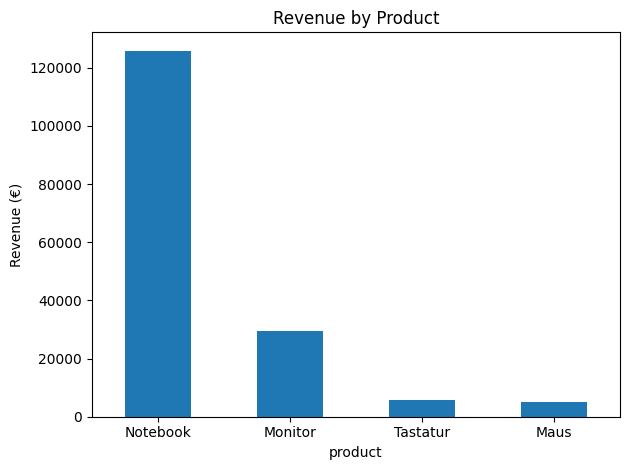

In [16]:
# Simple bar chart of revenue by product
ax = by_product.plot(kind="bar", title="Revenue by Product", ylabel="Revenue (€)", rot=0)
ax.figure.tight_layout()

## 6. Summary

Starting from a messy export with typos, mixed formats, duplicates and invalid
records, we produced a clean, validated dataset and derived clear KPIs.

**Cleaning steps applied:**
- Removed full-row duplicates
- Standardised product & city labels (whitespace, casing, typos)
- Parsed prices (`,`/`.`/`€` → float) and four date formats → datetime
- Coerced types and removed implausible quantities
- Dropped rows missing essential fields
- Added a derived `revenue` column

The clean file lives at `data/clean/sales_clean.csv` and is ready for any
downstream BI tool or further analysis.

**Skills shown:** pandas profiling, string normalisation & mapping, robust
type parsing, validation with assertions, groupby/resample aggregation.